## Lab07

- Marco Vinicio Ramirez Centes 21032
- Josué Isaac Morales Gonzalez 21116

In [ ]:
%pip install --user autogluon

In [1]:
import pandas as pd
# Importing pandas profiling
from  ydata_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt
import autogluon

#### Load the data

In [4]:
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


#### EDA

In [5]:
# Get basic descriptive statistics
descriptive_stats = diabetes_df.describe()
descriptive_stats

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Valores nulos

In [6]:
null_values = diabetes_df.isnull().sum()
null_values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

El dataset no contiene valores nulos

Pandas Profiler

In [7]:
# Generating a profile report for the insurance dataset
profile = ProfileReport(diabetes_df, title="Diabetes Data Profiling Report", explorative=True)

# Export the report to an HTML file
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Para visualizar el reporte generado, abra "insurance_data_profile_report.html"

<Axes: >

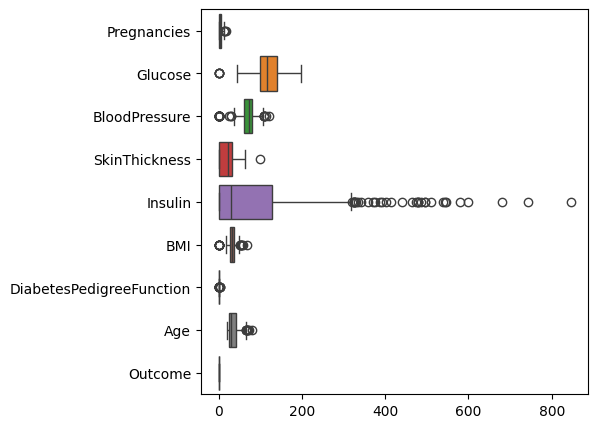

In [21]:
# Ensure plots are displayed inline in the notebook
%matplotlib inline

# Verify outliers
plt.figure(figsize=(5, 5))
sns.boxplot(data=diabetes_df, orient='h')

Existen valores atipicos en bmi y charges

In [24]:
# Calculate IQR for the numerical columns

Q1 = diabetes_df.quantile(0.25)
Q3 = diabetes_df.quantile(0.75)
IQR = Q3 - Q1

# Identifying outliers based on IQR
outliers = diabetes_df[((diabetes_df < (Q1 - 1.5 * IQR)) | 
                         (diabetes_df > (Q3 + 1.5 * IQR))).any(axis=1)]

outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
12,10,139,80,0,0,27.1,1.441,57,0
...,...,...,...,...,...,...,...,...,...
706,10,115,0,0,0,0.0,0.261,30,1
707,2,127,46,21,335,34.4,0.176,22,0
710,3,158,64,13,387,31.2,0.295,24,0
715,7,187,50,33,392,33.9,0.826,34,1


In [25]:
len(outliers)/len(diabetes_df) * 100

16.796875

Los outliers representan el 17% de todo el conjunto de datos. Por lo tanto no es viable eliminarlos.

#### Cap or Floor Outliers (Winsorization)

In [26]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
diabetes_df = diabetes_df.clip(lower=lower_bound, upper=upper_bound, axis=1)


Reemplazo de los valores extremos con los valores límite más cercanos.
Este puede ser un enfoque intermedio en el que aún se tienen en cuenta los valores atípicos, pero se reduce su impacto.

#### Autogluon

El conjunto representa los datos de personas que utilizan cierta aseguradora. Por lo tanto, se plantea un problema de regresión respecto a los cargos que pueda tener una persona según sus características.

In [31]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import confusion_matrix

# Verify the columns in the dataframe
print(diabetes_df.columns)

# Assuming 'Outcome' is the target variable, update the label accordingly
predictor = TabularPredictor(label='Outcome', eval_metric='accuracy').fit(
    train_data=diabetes_df, 
    presets='best_quality'
)

# View leaderboard of models
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard)

# Display a fit summary
predictor.fit_summary()

# Make predictions on the training dataset (diabetes_df)
predictions = predictor.predict(diabetes_df)

# Generate the confusion matrix using true labels and predicted labels
cm = confusion_matrix(diabetes_df['Outcome'], predictions)

# Print the confusion matrix
print("Confusion Matrix (Training Data):")
print(cm)

No path specified. Models will be saved in: "AutogluonModels\ag-20241001_220812"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.9.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22621
CPU Count:          12
Memory Avail:       2.83 GB / 15.73 GB (18.0%)
Disk Space Avail:   4.69 GB / 120.00 GB (3.9%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


Leaderboard on holdout data (DyStack):
                          model  score_holdout  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0               LightGBM_BAG_L1       0.790698   0.800587    accuracy        0.608335       0.008190    1.131055                 0.608335                0.008190           1.131055            1       True          4
1            XGBoost_r33_BAG_L1       0.779070   0.781525    accuracy        0.701638       0.028018    1.985835                 0.701638                0.028018           1.985835            1       True         21
2       RandomForestEntr_BAG_L1       0.767442   0.750733    accuracy        0.339723       0.187512    1.176557                 0.339723                0.187512           1.176557            1       True          6
3                XGBoost_BAG_L1       0.767442   0.793255    accuracy        0.635254       0.024

                      model  score_val eval_metric  pred_time_val  \
0       WeightedEnsemble_L3   0.839844    accuracy      22.270578   
1           CatBoost_BAG_L2   0.835938    accuracy      22.254430   
2         LightGBMXT_BAG_L2   0.833333    accuracy      22.057856   
3      CatBoost_r177_BAG_L2   0.833333    accuracy      22.193831   
4           LightGBM_BAG_L2   0.832031    accuracy      22.046225   
..                      ...        ...         ...            ...   
82  RandomForest_r34_BAG_L1   0.757812    accuracy       0.305367   
83  RandomForest_r39_BAG_L1   0.755208    accuracy       0.729444   
84    ExtraTrees_r42_BAG_L1   0.751302    accuracy       0.071381   
85    KNeighborsUnif_BAG_L1   0.722656    accuracy       0.443629   
86    KNeighborsDist_BAG_L1   0.722656    accuracy       0.453778   

       fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  \
0   1772.433293                0.000000           0.514110            3   
1   1765.509034      

C:\Users\bcarr\AppData\Roaming\Python\Python39\site-packages\autogluon\core\utils\plots.py:169: UserWarning: AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"
  warnings.warn('AutoGluon summary plots cannot be created because bokeh is not installed. To see plots, please do: "pip install bokeh==2.0.1"')


Confusion Matrix (Training Data):
[[434  66]
 [101 167]]


2024-10-01 17:15:00,908	ERROR worker.py:406 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2024-10-01 17:15:00,915	ERROR worker.py:406 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.


Según la tabla desplegada, el mejor modelo es el obtenido con el algoritmo WeightedEnsemble_L3, con un accuracy de 0.839844

#### Reflexión

Las herramientas de AutoML, como AutoGluon, simplifican el aprendizaje automático al automatizar tareas complejas, haciéndolo accesible para quienes no son expertos, aunque también presentan ciertas limitaciones. A continuación, se destacan sus principales beneficios y desventajas:

#### Beneficios:
- **Facilidad de uso**: Permiten que personas sin experiencia técnica puedan desarrollar modelos de machine learning eficientes.
- **Rapidez**: Exploran varios modelos y configuraciones en poco tiempo, optimizando el proceso.
- **Automatización de características**: Detectan las características más relevantes y crean nuevas de manera automática.
- **Selección automática de modelos**: Evalúan distintas opciones de modelos y seleccionan el que mejor se ajusta a los datos.
- **Optimización de tiempo**: Reducen la carga manual al automatizar el ajuste de hiperparámetros y el entrenamiento.
- **Rendimiento competitivo**: Pueden alcanzar o incluso superar a modelos diseñados manualmente por usuarios no especializados.

#### Desventajas:
- **Limitaciones en la personalización**: El nivel de control y ajuste sobre los modelos generados es limitado.
- **Dificultad en la interpretación**: Los modelos son difíciles de interpretar, lo que complica entender sus decisiones.
- **Posibles compromisos en el rendimiento**: No siempre ofrecen los resultados más óptimos.
- **Consumo elevado de recursos**: Requieren una gran cantidad de recursos computacionales y tiempo.
- **Riesgo de sobreajuste**: Pueden ajustarse demasiado a los datos si no se valida correctamente.
- **Limitaciones en la creación de características**: No sustituyen la experiencia experta en algunos casos específicos.

En conclusión, AutoML acelera el proceso de desarrollo de modelos, siendo especialmente útil para usuarios sin experiencia técnica, aunque puede presentar restricciones en cuanto a personalización, interpretación y rendimiento en contextos específicos.